# <center> Trend of EV Adoption in Singapore

### <center> Project Proposal

## 1. Aims, Objectives and Background
### 1.1 Introduction

<br>
In this ever-changing landscape of global transportation, the paradigm is gearing towards sustainable alternatives, and being one of the fastest developed countries in the world, Singappore is at the forefront of this vehicular revolution. The increasing concerns abouut environmental sustainability has fueled the adoption of electric vehicles (EVs) in this tiny country and worldwide. 
<br><br>
This project is an attempt to dig deeper into the factors affecting the trend of electric vehicle adoption in Singapore, observe the trend and challenges, and if possible, predict the future prospects of EVs in Singapore.


### 1.2 Motivation and Background
The Singapore government, specifically the Land Transport Authority (LTA), has decided on an ambitious goal to reduce land transport emissions by 80% by the mid-century.[1] Given Singapore's reliance on natural gas for power generation, transitioning from internal combustion engine (ICE) vehicles to electric vehicles (EVs) is a sustainable choice. With this in mind, they've introduced the "Singapore Green Plan 2030", a comprehensive EV Roadmap to drive the adoption of electric vehicles. Under this roadmap, Singapore aims to establish 60,000 EV charging points by 2030: 40,000 in public carparks and 20,000 in private premises. One important thing to note is that, the public housing board in Singapore i.e., Housing and Development Board (HDB) endeavors each HDB town to be an EV-Ready Town, with around 2,000 carparks equipped with charging points by 2025. 
<br><br>
However, every Singaporean knows how expensive owning a car is in the country right now with the increasing COE (Certificate of Entitlement) prices; the next thing that's more expensive is owning an apartment in Singapore, even one under HDB.
<br><br>
Will the hoi polloi of the nation be able to adopt this new trend of transitioning to a much more expensive, albeit sustainable, way of owning a car? Or will the charging points installed ultimately be a waste of time, effort and money by the government? That's the question this project is aiming to explore.

### 1.3 Aims and Objectives
This report aims to use data science webscrapping to investigate the trend of EV adoption currently (i.e., volume of new registration of EV cars by make, EV population ), the reasons for the adoption/non-adoption and the general sentiments the locals have towards electric vehicles. A further analysis might be taken to find out the demographics of people buying EVs within the data period specified in the project scope. The next step will be to source for another country's EV adoption trend (i.e., Norway) to compare the findings. 


### 1.4 Scope
Having spoken to a personnel working at a local private company involved in the installation of EV charging stations in Singapore, I've decided that the scope of this project will deal with data and information within the last 3 years (2021 - 2023) as Singapore is still relatively new to the EV scene. Also, from the dataset, I will only be looking at electric vehicles, hybrids like petrol-electric or diesel-electric will not be considered in order to align with the  goals of the EV Roadmap. Taxis and other form of electric vehicles like motorcycles and buses will not be taken into consideration as well for the purpose of this project.




## 2. Data

### 2.1 Data Requirements and Chosen Organisations
I will be using statistical data and publications from the LTA website (including its subsidiary OneMotoring), local newspaper website The Straits Times and also the local English news channel - Channel News Asia (CNA)'s website to webscrape for information for this project.

### 2.2 Type of Data
2 sets of static csv files will be used:
- Monthly New Registration of Cars by Make (DataMall, LTA)
- Monthly Motor Vehicle Population Statistics by Type of Fuel Used (DataMal, LTA)



## 3. Limitations

### 3.1 Limitations of Approach
One limitation is that the qualitative data gathered from the LTA, The Straits Times and CNA websites might be skewed as those three are government websites. Extreme or negative sentiments might be filtered. As EVs are still relatively new to the country, there are not enough forums or publications at the moment to paint a more accurate picture of the EV adoption scene in the country.

### 3.2 Limitations of dataset
The dataset is only exploring a period of 3 years, this may or may not be a long enough period to show a significant trend. 

For CSV file - Monthly New Registration of Cars by Make, as EVs have only been appearing in Singapore during the recent years, they were documented as "Others" under "fuel_type", it's only in the current times that they are labelled as "electric" in the dataset. "Others" can also mean non-EV type of cars as well, so that may affect the accuracy of the analysis. Nonetheless, for this project's purpose, we'll include "Others" numbers in our analysis as well. 

## 4. Ethics

### 4.1 Ownership and Provenance
The data sourced from the Land Transport Authority (LTA) website, local newspaper website The Straits Times and Channel News Asia (CNA)'s website are handled with transparency regarding its provenance. Acknowledgment of the ownership of the data, highlighting that it comes from the LTA and CNA is mandatory in this project.

### 4.2 Data Preparation, Refinement, and Exploration
The two sets of CSV files obtained from LTA are used in accordance with the terms of use specified by LTA. Any insights or analysis derived from the data will be attributed to the original sources.

### 4.3 Potential Biases in the Dataset
As these data are retrieved from government websites, spotting inherent biases that might exist is crucial and will be mitigated during analysis.

## 5. Libraries and Modules

In [1]:
# Import Libraries and Modules
import pandas as pd
from tabulate import tabulate
from decimal import Decimal
from bs4 import BeautifulSoup
import json
import requests
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np
from PIL import Image
import re
from re import sub
import time
from nltk.stem import WordNetLemmatizer

# Set all graphs to a seaborn style with a grey background grid which makes reading graphs easier
# sns.set()


## 6. Extraction of Data and Webscraping



### 6.1 Extract data from CSV File


#### 6.1.1 Monthly Motor Vehicle Population Statistics by Type of Fuel Used
Let's first clean the data from the 1st CSV file. 

In [22]:
df = pd.read_csv('M09-Vehs_by_Fuel_Type.csv',encoding = "utf-8")

##### A. Clean data to filter out only electric cars for years 2021 to 2023

In [55]:
# Convert the 'month' column to a datetime object for easy comparison
df['month'] = pd.to_datetime(df['month'])

# Filter for the years 2021 to 2023, 'Electric' type, and 'Cars' category
filtered_df = df[(df['month'].dt.year >= 2021) & 
                  (df['month'].dt.year <= 2023) & 
                  (df['type'] == 'Electric') &
                  (df['category'] == 'Cars')]

# Convert the 'number' column to integers 
filtered_df.loc[:, 'number'] = filtered_df['number'].astype(int)

# Display the filtered dataframe
print(tabulate(filtered_df, headers='keys', tablefmt='pretty'))

+------+---------------------+----------+----------+--------+
|      |        month        | category |   type   | number |
+------+---------------------+----------+----------+--------+
| 1709 | 2021-01-01 00:00:00 |   Cars   | Electric |  1274  |
| 1738 | 2021-02-01 00:00:00 |   Cars   | Electric |  1307  |
| 1767 | 2021-03-01 00:00:00 |   Cars   | Electric |  1351  |
| 1796 | 2021-04-01 00:00:00 |   Cars   | Electric |  1415  |
| 1825 | 2021-05-01 00:00:00 |   Cars   | Electric |  1485  |
| 1854 | 2021-06-01 00:00:00 |   Cars   | Electric |  1549  |
| 1883 | 2021-07-01 00:00:00 |   Cars   | Electric |  1643  |
| 1912 | 2021-08-01 00:00:00 |   Cars   | Electric |  1855  |
| 1941 | 2021-09-01 00:00:00 |   Cars   | Electric |  2243  |
| 1970 | 2021-10-01 00:00:00 |   Cars   | Electric |  2309  |
| 1999 | 2021-11-01 00:00:00 |   Cars   | Electric |  2635  |
| 2028 | 2021-12-01 00:00:00 |   Cars   | Electric |  2942  |
| 2057 | 2022-01-01 00:00:00 |   Cars   | Electric |  3149  |
| 2086 |

##### B.Graphical Representation: Plot line graphs to show trend across each year

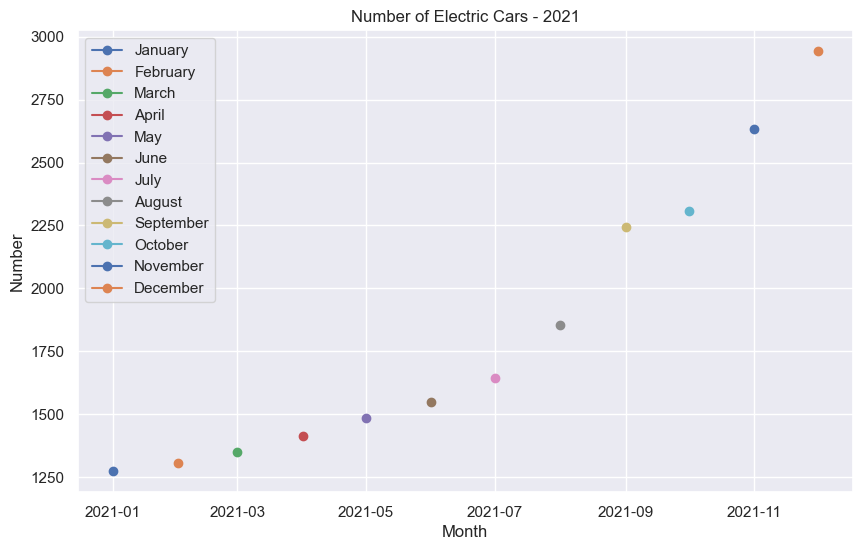

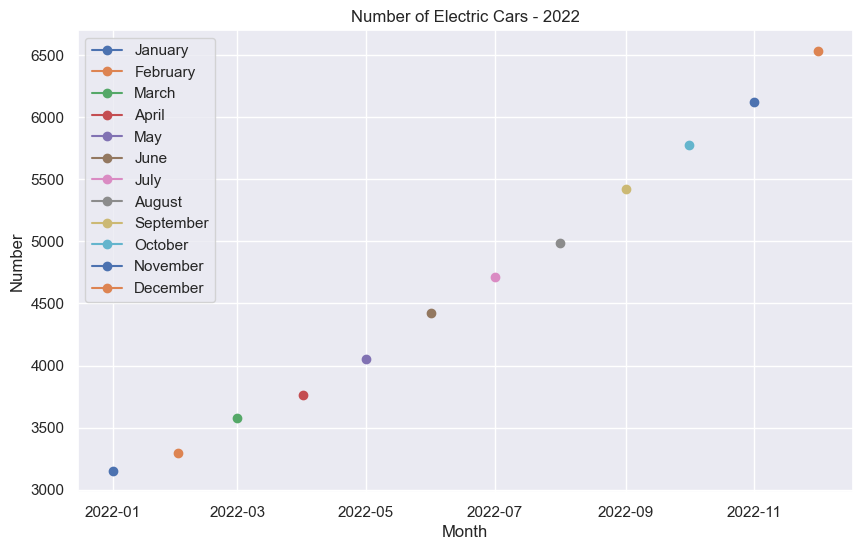

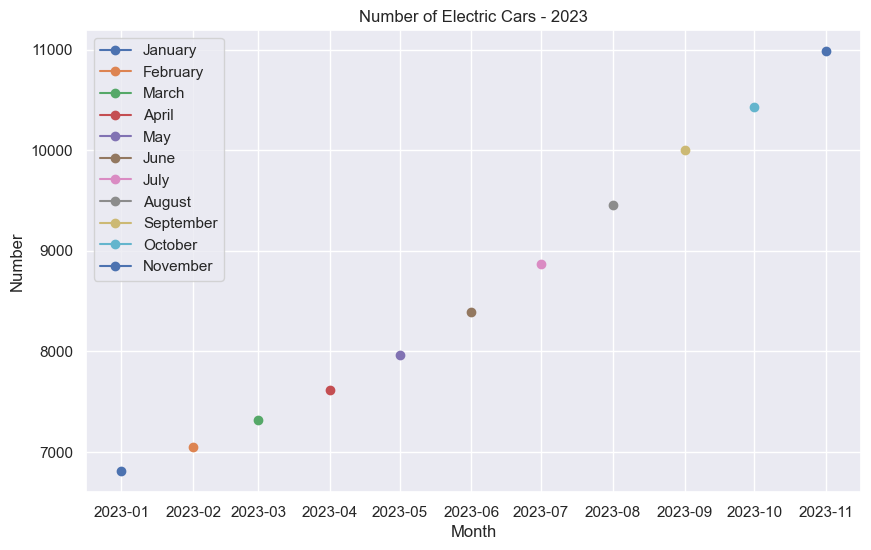

In [47]:
# Convert the 'month' column to a datetime object for easy comparison
df['month'] = pd.to_datetime(df['month'])

# Filter for the years 2021 to 2023, 'Electric' type, and 'Cars' category
filtered_df = df[(df['month'].dt.year >= 2021) & 
                  (df['month'].dt.year <= 2023) & 
                  (df['type'] == 'Electric') &
                  (df['category'] == 'Cars')]

# Convert the 'number' column to integers 
filtered_df.loc[:, 'number'] = filtered_df['number'].astype(int)

# Create a separate line graph for each year
for year, group in filtered_df.groupby(filtered_df['month'].dt.year):
    plt.figure(figsize=(10, 6))
    for index, row in group.iterrows():
        plt.plot(row['month'], row['number'], marker='o', label=f"{row['month'].strftime('%B')}")
    
    plt.title(f'Number of Electric Cars - {year}')
    plt.xlabel('Month')
    plt.ylabel('Number')
    plt.legend()
    plt.show()

Analysis: We can tell from graph for 2021 that there was an overall increasing trend over the months during that year. This has sustained till 2022 but as we reached 2023 the trend has dipped slightly. We can corroborate this trend with the sentiment analysis from webscraping the chosen articles from the news websites to understand the factors causing the trend. 

##### C. Graphical representation: Plot line graphs to compare the 3 annual trends together in one graph

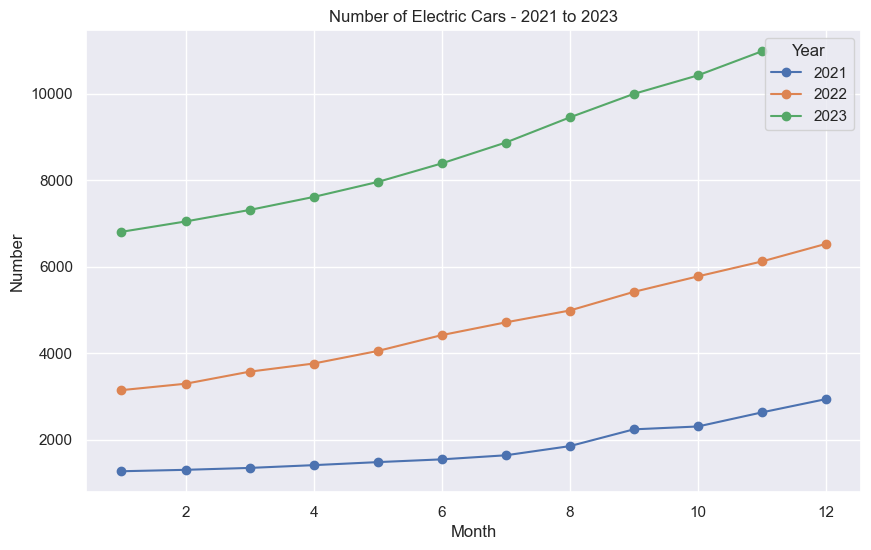

In [56]:
# Convert the 'month' column to a datetime object for easy comparison
df['month'] = pd.to_datetime(df['month'])

# Filter for the years 2021 to 2023, 'Electric' type, and 'Cars' category
filtered_df = df[(df['month'].dt.year >= 2021) & 
                  (df['month'].dt.year <= 2023) & 
                  (df['type'] == 'Electric') &
                  (df['category'] == 'Cars')]

# Convert the 'number' column to integers 
filtered_df.loc[:, 'number'] = filtered_df['number'].astype(int)

# Create a single line graph with different colors for each year
plt.figure(figsize=(10, 6))

for year, group in filtered_df.groupby(filtered_df['month'].dt.year):
    plt.plot(group['month'].dt.month, group['number'], label=f"{year}", marker='o')

plt.title('Number of Electric Cars - 2021 to 2023')
plt.xlabel('Month')
plt.ylabel('Number')
plt.legend(title='Year')
plt.show()

Analysis: This graph here shows a distinct jump in the EV population between 2022 and 2023. Again, we can find more information through sentiment analysis of the news articles to find out what caused this big jump.

##### D. Final population of electric cars for each year

In [82]:
# Convert 'number' column to Decimal and then calculate the sum for each year
sum_by_year = filtered_df.groupby(filtered_df['month'].dt.year)['number'].sum().apply(Decimal)

# Rename the index to 'Year'
sum_by_year.index.name = 'Year'

# Create a DataFrame from the Series
sum_by_year_df = pd.DataFrame(sum_by_year).reset_index()

# Display the sum for each year using tabulate
print(tabulate(sum_by_year_df, headers='keys', tablefmt='pretty'))

+---+------+--------+
|   | Year | number |
+---+------+--------+
| 0 | 2021 | 15294  |
| 1 | 2022 | 10071  |
| 2 | 2023 |  4506  |
+---+------+--------+


#### 6.1.2 Monthly New Registration of Cars by Make
Let's first clean the data from the 2nd CSV file. 

##### A. Clean data to filter out only electric cars for years 2021 to 2023

In [76]:
df = pd.read_csv('M03-Car_Regn_by_make.csv', encoding='utf-8')

# Convert the 'month' column to a datetime object for easy comparison
df['month'] = pd.to_datetime(df['month'])

# Filter for the years 2021 to 2023, 'Electric' type, and 'Cars' category
filtered_df = df[(df['month'].dt.year >= 2021) & 
                  (df['month'].dt.year <= 2023) & 
                  (df['fuel_type'].isin(['Electric', 'Others']))]

# Drop rows with non-finite values in the 'number' column
filtered_df = filtered_df.dropna(subset=['number'])

# Convert the 'number' column to integers 
filtered_df['number'] = filtered_df['number'].astype(int)

# Remove the 'importer_type' column
filtered_df = filtered_df.drop(columns=['importer_type'])

# Remove the 'vehicle_type' column
filtered_df = filtered_df.drop(columns=['vehicle_type'])

# Display the first 5 and last 5 rows with ellipses in between
print(tabulate(pd.concat([filtered_df.head(), pd.DataFrame(index=['...']), filtered_df.tail()]), headers='keys', tablefmt='pretty'))

# Convert 'number' column to Decimal and then calculate the sum for each year
sum_by_year = filtered_df.groupby(filtered_df['month'].dt.year)['number'].sum().apply(Decimal)

# Rename the index to 'Year'
sum_by_year.index.name = 'Year'

# Create a DataFrame from the Series
sum_by_year_df = pd.DataFrame(sum_by_year).reset_index()

# Display the sum for each year using tabulate
print(tabulate(sum_by_year_df, headers='keys', tablefmt='pretty'))

+-------+---------------------+---------+-----------+--------+
|       |        month        |  make   | fuel_type | number |
+-------+---------------------+---------+-----------+--------+
| 20939 | 2021-01-01 00:00:00 |  AUDI   |  Others   |  33.0  |
| 20943 | 2021-01-01 00:00:00 |   BYD   |  Others   |  15.0  |
| 20948 | 2021-01-01 00:00:00 |  HONDA  |  Others   |  7.0   |
| 20950 | 2021-01-01 00:00:00 | HYUNDAI |  Others   |  7.0   |
| 20969 | 2021-01-01 00:00:00 |  MAZDA  |  Others   |  36.0  |
|  ...  |         NaT         |   nan   |    nan    |  nan   |
| 39375 | 2023-11-01 00:00:00 |  TESLA  | Electric  |  28.0  |
| 39379 | 2023-11-01 00:00:00 | TOYOTA  | Electric  |  2.0   |
| 39389 | 2023-11-01 00:00:00 |  VOLVO  | Electric  |  9.0   |
| 39424 | 2023-11-01 00:00:00 |  FIAT   | Electric  |  1.0   |
| 39495 | 2023-11-01 00:00:00 |  SKODA  | Electric  |  1.0   |
+-------+---------------------+---------+-----------+--------+
+---+------+--------+
|   | Year | number |
+---+------

##### B. Top makes for each year


Top Makes for the Year 2021:

+----+---------------+-----------+--------------+
|    |     Make      | Fuel Type | Total Number |
+----+---------------+-----------+--------------+
| 0  |    TOYOTA     |  Others   |     5557     |
| 1  |    NISSAN     |  Others   |     1519     |
| 2  |     MAZDA     |  Others   |     1228     |
| 3  | MERCEDES BENZ |  Others   |     1103     |
| 4  |     AUDI      |  Others   |     1056     |
| 5  |     TESLA     |  Others   |     924      |
| 6  |     HONDA     |  Others   |     905      |
| 7  |    B.M.W.     |  Others   |     900      |
| 8  |      KIA      |  Others   |     428      |
| 9  |    HYUNDAI    |  Others   |     372      |
| 10 |    SUZUKI     |  Others   |     224      |
| 11 |  LAND ROVER   |  Others   |     189      |
| 12 |     VOLVO     |  Others   |     134      |
| 13 |    PORSCHE    |  Others   |     131      |
| 14 |     M.G.      |  Others   |     129      |
| 15 |  VOLKSWAGEN   |  Others   |     105      |
| 16 |     SKODA   

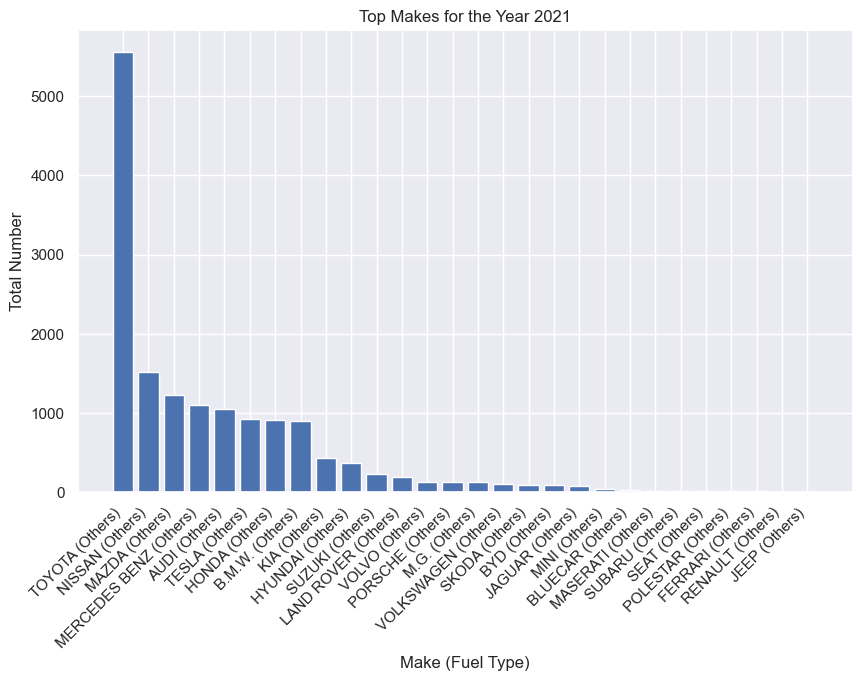


Top Makes for the Year 2022:

+----+---------------+-----------+--------------+
|    |     Make      | Fuel Type | Total Number |
+----+---------------+-----------+--------------+
| 0  |    TOYOTA     |  Others   |     2354     |
| 1  | MERCEDES BENZ |  Others   |     1453     |
| 2  |    B.M.W.     |  Others   |     575      |
| 3  |     TESLA     | Electric  |     560      |
| 4  |      BYD      | Electric  |     486      |
| 5  |    NISSAN     |  Others   |     450      |
| 6  |     MAZDA     |  Others   |     389      |
| 7  |     HONDA     |  Others   |     370      |
| 8  |     AUDI      |  Others   |     354      |
| 9  |     TESLA     |  Others   |     315      |
| 10 |    B.M.W.     | Electric  |     314      |
| 11 |    HYUNDAI    |  Others   |     307      |
| 12 |      BYD      |  Others   |     300      |
| 13 | MERCEDES BENZ | Electric  |     219      |
| 14 |     VOLVO     |  Others   |     183      |
| 15 |      KIA      |  Others   |     182      |
| 16 |     M.G.    

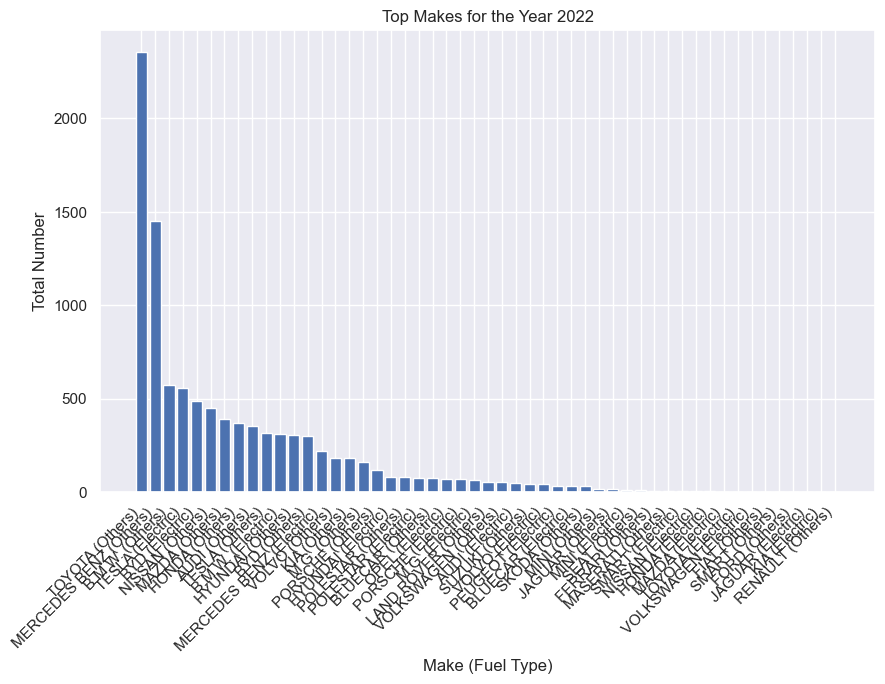


Top Makes for the Year 2023:

+----+---------------+-----------+--------------+
|    |     Make      | Fuel Type | Total Number |
+----+---------------+-----------+--------------+
| 0  |      BYD      | Electric  |     1143     |
| 1  |     TESLA     | Electric  |     725      |
| 2  |    B.M.W.     | Electric  |     701      |
| 3  |    HYUNDAI    | Electric  |     514      |
| 4  | MERCEDES BENZ | Electric  |     488      |
| 5  |     VOLVO     | Electric  |     143      |
| 6  |     M.G.      | Electric  |     143      |
| 7  |    PORSCHE    | Electric  |     111      |
| 8  |     OPEL      | Electric  |     105      |
| 9  |    PEUGEOT    | Electric  |     100      |
| 10 |   POLESTAR    | Electric  |      92      |
| 11 |     AUDI      | Electric  |      47      |
| 12 |      KIA      | Electric  |      44      |
| 13 |    TOYOTA     | Electric  |      39      |
| 14 |  GREAT WALL   | Electric  |      39      |
| 15 |    CITROEN    | Electric  |      14      |
| 16 |     MAZDA   

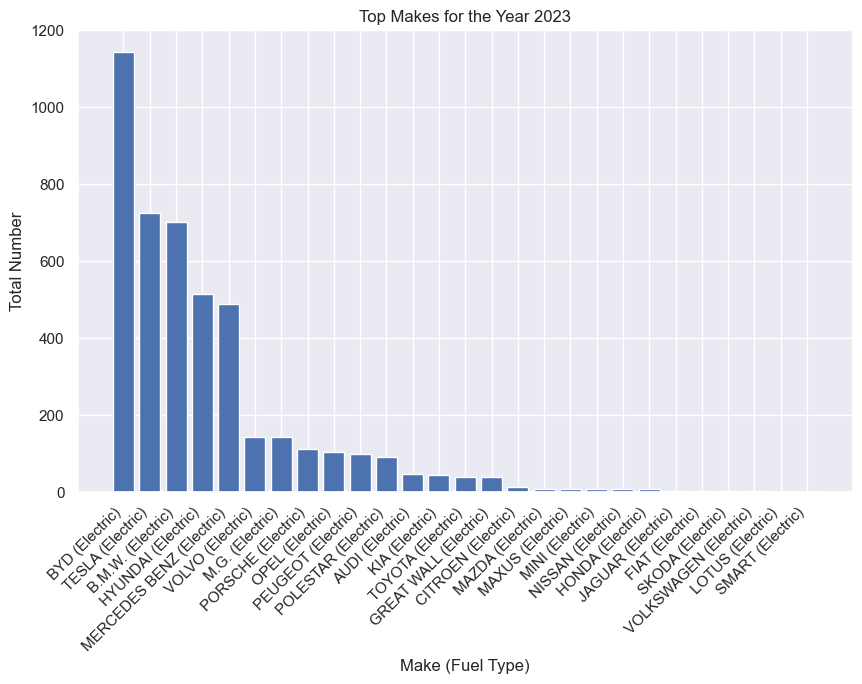

In [80]:

# Convert the 'month' column to a datetime object for easy comparison
df['month'] = pd.to_datetime(df['month'])

# Filter for the years 2021 to 2023, 'Electric' type, and 'Cars' category
filtered_df = df[(df['month'].dt.year.isin([2021, 2022, 2023])) & 
                  (df['fuel_type'].isin(['Electric', 'Others']))]

# Drop rows with non-finite values in the 'number' column
filtered_df = filtered_df.dropna(subset=['number'])

# Convert the 'number' column to integers 
filtered_df['number'] = filtered_df['number'].astype(int)

# Group by 'make', 'fuel_type', and 'year', sum the 'number' column
make_sum = filtered_df.groupby(['make', 'fuel_type', filtered_df['month'].dt.year])['number'].sum()

# Sort the values in descending order
make_sum = make_sum.sort_values(ascending=False)

# Create tables and plot graphs for each year
for year, group in make_sum.groupby(level=2):
    make_table = pd.DataFrame({'Make': group.index.get_level_values('make'),
                               'Fuel Type': group.index.get_level_values('fuel_type'),
                               'Total Number': group.values})
    
    # Display the table
    print(f"\nTop Makes for the Year {year}:\n")
    print(tabulate(make_table, headers='keys', tablefmt='pretty'))

    # Bar chart for better visualization
    plt.figure(figsize=(10, 6))
    plt.bar(make_table['Make'] + ' (' + make_table['Fuel Type'] + ')', make_table['Total Number'])
    plt.xlabel('Make (Fuel Type)')
    plt.ylabel('Total Number')
    plt.title(f'Top Makes for the Year {year}')
    plt.xticks(rotation=45, ha='right')
    plt.show()

### 6.2 Webscraping from websites

#### 6.2.1 Defining functions for Web Scraping 


In [90]:
def get_soup(url, jar=None):
    # Create a session for better cookie handling
    session = requests.Session()

    # Check page accessibility
    try:
        if jar:
            response = session.get(url, cookies=jar)
        else:
            response = session.get(url)
        response.raise_for_status()  
    except requests.exceptions.RequestException as e:
        print(f"Error accessing {url}: {e}")
        return None, None

    print(response.url)
    data = response.text
    soup = BeautifulSoup(data, 'html.parser')
    return soup, session.cookies

In [91]:
soup, jar = get_soup('https://www.channelnewsasia.com/singapore/charging-points-importing-rules-hamper-electric-vehicle-adoption-singapore-3408101')
jar

https://www.channelnewsasia.com/singapore/charging-points-importing-rules-hamper-electric-vehicle-adoption-singapore-3408101


<RequestsCookieJar[]>

#### 6.2.2 Singaporeans' attitude towards EV adoption

#### A. Wordcloud to spot recurring words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\devon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


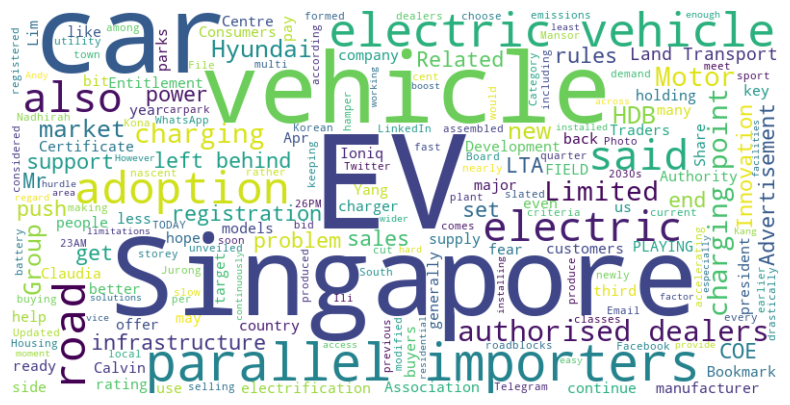

In [118]:
# Download NLTK stopwords data
nltk.download('stopwords')

def get_article_info(url):
    response = requests.get(url)
    response.raise_for_status()

    soup = BeautifulSoup(response.content, 'html.parser')

    # Extract text content from the article
    content_elements = soup.find_all('div', class_='content')
    content = ' '.join(element.get_text() for element in content_elements)
    
    return {'content': content.strip()}

url = 'https://www.channelnewsasia.com/singapore/charging-points-importing-rules-hamper-electric-vehicle-adoption-singapore-3408101'
article_info = get_article_info(url)

# Generate Word Cloud excluding common English stopwords
if article_info and 'content' in article_info and article_info['content']:
    content = article_info['content']

    # Use NLTK stopwords in addition to the default set
    stopwords_set = set(stopwords.words('english'))
    
    # Create WordCloud with stopwords
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_set).generate(content)

    # Plot the WordCloud image
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()
else:
    print("No valid content found for word cloud.")

## 7. Conclusion
The data analysis from the 2 CSV files obtained from LTA shows an increasing trend in electric vehicle population from 2021 to 2023, which shows a positive adoption of EVs in Singapore. Additionally, we discovered that BYD and Tesla are gaining more popularity as well across the 3 years, which can be explained by the two companies' increasing R&D effort at releasing new and more efficient models of cars to the EV market. 



## 8. References
[1] Land Transport Authority. (2023). Our EV Vision. [online] Available at: https://www.lta.gov.sg/content/ltagov/en/industry_innovations/technologies/electric_vehicles/our_ev_vision.html

[2] Channel News Asia. (2023). Limited charging points, rules over sales hamper electric vehicle adoption in Singapore. [online] Available at: https://www.channelnewsasia.com/singapore/charging-points-importing-rules-hamper-electric-vehicle-adoption-singapore-3408101

[3] Channel News Asia. (2022). Public infrastructure upgrade key to boosting electric vehicles adoption in Singapore. [online] Available at: https://www.channelnewsasia.com/singapore/singapore-electric-vehicle-charging-clean-energy-southeast-asia-decarbonisation-wwf-3169326

[4] Channel News Asia. (2022). Enhanced Vehicular Emissions Scheme to be extended until 2025. [online] Available at: https://www.channelnewsasia.com/singapore/ves-enhanced-vehicular-emissions-scheme-extended-until-2025-nea-lta-2782836

[5] Channel News Asia. (2022). IN FOCUS: Singapore's electric vehicle revolution is coming - does this spell the end for petrol stations? [online] Available at: https://www.channelnewsasia.com/singapore/focus-singapores-electric-vehicle-revolution-coming-does-spell-end-petrol-stations-2768051

[6] Channel News Asia. (2022). Take-up for electric cars jumps, registrations this year already twice the rate for all of 2021: Iswaran. [online] Available at: https://www.channelnewsasia.com/singapore/electric-cars-registration-ev-green-transport-sustainability-2733691


[7] Land Transport Authority: DataMall (2023). Static Datasets. [online] Available at: https://datamall.lta.gov.sg/content/datamall/en/static-data.html


[8] The Straits Times (2023). BYD zooms past Tesla to become S’pore’s best-selling electric vehicle brand. [online] Available at: https://www.straitstimes.com/singapore/transport/byd-leads-ev-sales-race-in-2023-long-time-leader-tesla-falls-to-second-place-followed-by-bmw#:~:text=According%20to%20the%20LTA%20figures,11.7%20per%20cent%20in%202022.


[9] Statista. Electric Vehicles - Singapore. [online] Available at: https://www.statista.com/outlook/mmo/electric-vehicles/singapore